# Experiment 1 - Feature Selection
번아웃과 상관계수가 낮은 feature를 포함했을 때 vs 제외했을 때 비교

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## 1. 데이터 로드 및 결측치 처리

In [4]:
data = pd.read_csv('/content/sample_data/developer_burnout_dataset_7000.csv')
print('데이터 크기:', data.shape)
data.head()

데이터 크기: (7000, 12)


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [5]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data['burnout_level'].fillna(data['burnout_level'].mode()[0], inplace=True)
print('결측치 처리 후:')
print(data.isnull().sum())

결측치 처리 후:
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64


/tmp/ipykernel_904/175315617.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['burnout_level'].fillna(data['burnout_level'].mode()[0], inplace=True)


## 2. 타겟 라벨 인코딩

In [6]:
data['burnout_level'] = data['burnout_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
print(data['burnout_level'].value_counts())

burnout_level
1    3625
2    1782
0    1593
Name: count, dtype: int64


## 3. 상관관계 시각화 (EDA)

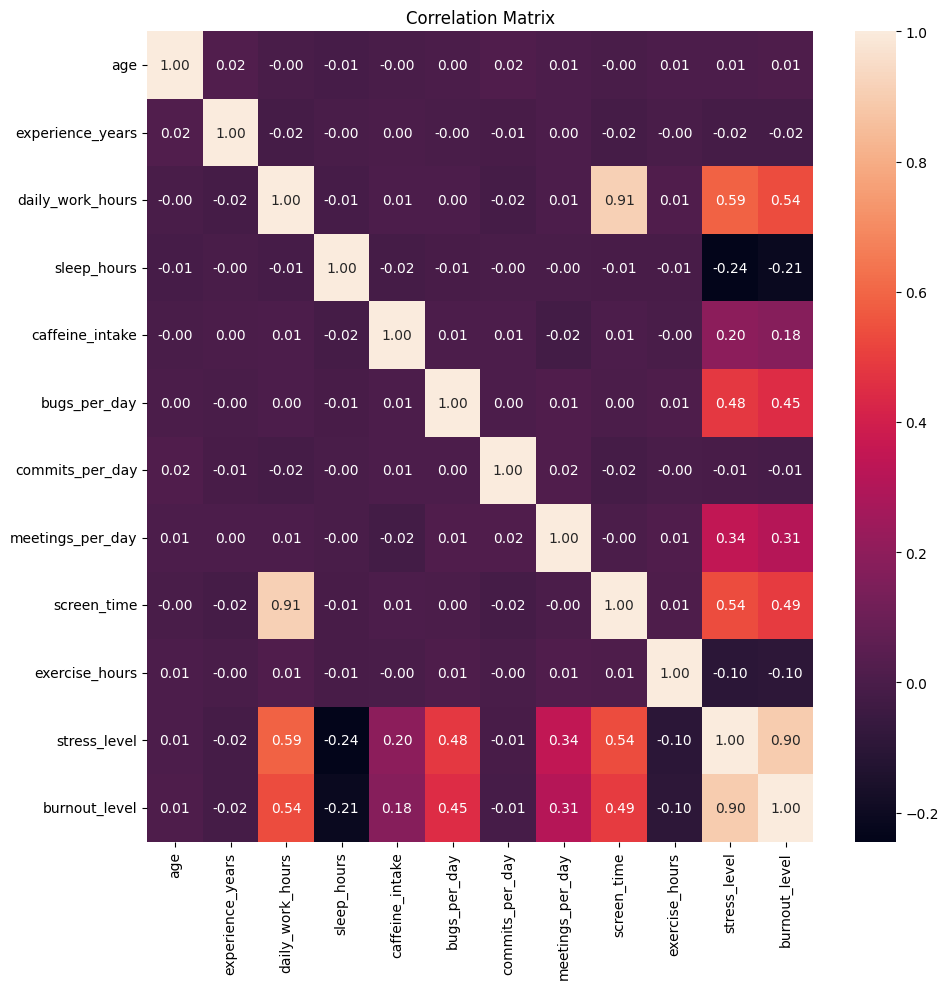

burnout_level 기준 상관계수:
burnout_level       1.000000
stress_level        0.896386
daily_work_hours    0.536292
screen_time         0.490422
bugs_per_day        0.448993
meetings_per_day    0.314284
caffeine_intake     0.176621
age                 0.011567
commits_per_day    -0.012135
experience_years   -0.017835
exercise_hours     -0.096449
sleep_hours        -0.212185
Name: burnout_level, dtype: float64


In [7]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='0.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('burnout_level 기준 상관계수:')
print(data.corr(numeric_only=True)['burnout_level'].sort_values(ascending=False))

**EDA 결과**

- stress_level: 상관계수 0.91 → 너무 높아서 제외 (정보 누수 우려)
- daily_work_hours, screen_time, bugs_per_day: 중간 이상 상관관계 → 유의미
- age, experience_years, commits_per_day, exercise_hours: 상관계수 0.02 이하 → 거의 무관

**실험 설계**

- feature_all: stress_level 제외한 전체 10개 feature
- feature_high: 상관계수 높은 6개 feature만 사용

## 4. Feature / Target 정의 및 데이터 분할

In [8]:
feature_all  = ['age', 'experience_years', 'daily_work_hours', 'sleep_hours',
                'caffeine_intake', 'bugs_per_day', 'commits_per_day',
                'meetings_per_day', 'screen_time', 'exercise_hours']

feature_high = ['daily_work_hours', 'sleep_hours', 'caffeine_intake',
                'bugs_per_day', 'meetings_per_day', 'screen_time']

target = ['burnout_level']

X_train_all,  X_test_all,  y_train_all,  y_test_all  = train_test_split(
    data[feature_all],  data[target], test_size=0.2, random_state=40)

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    data[feature_high], data[target], test_size=0.2, random_state=41)

## 5. 정규화 및 Tensor 변환

In [9]:
sc  = StandardScaler()
sc1 = StandardScaler()

X_train_all  = sc.fit_transform(X_train_all)
X_test_all   = sc.transform(X_test_all)
X_train_high = sc1.fit_transform(X_train_high)
X_test_high  = sc1.transform(X_test_high)

X_train_all  = torch.FloatTensor(X_train_all)
X_test_all   = torch.FloatTensor(X_test_all)
y_train_all  = torch.FloatTensor(y_train_all.values)
y_test_all   = torch.FloatTensor(y_test_all.values)
X_train_high = torch.FloatTensor(X_train_high)
X_test_high  = torch.FloatTensor(X_test_high)
y_train_high = torch.FloatTensor(y_train_high.values)
y_test_high  = torch.FloatTensor(y_test_high.values)

print(X_train_all.shape, y_train_all.shape)
print(X_train_high.shape, y_train_high.shape)

torch.Size([5600, 10]) torch.Size([5600, 1])
torch.Size([5600, 6]) torch.Size([5600, 1])


## 6. DataLoader

In [10]:
train_all_loader  = DataLoader(TensorDataset(X_train_all,  y_train_all),  batch_size=64, shuffle=True)
test_all_loader   = DataLoader(TensorDataset(X_test_all,   y_test_all),   batch_size=64, shuffle=False)
train_high_loader = DataLoader(TensorDataset(X_train_high, y_train_high), batch_size=64, shuffle=True)
test_high_loader  = DataLoader(TensorDataset(X_test_high,  y_test_high),  batch_size=64, shuffle=False)

## 7. 모델 정의

In [11]:
class BurnoutModel(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layer1 = nn.Linear(input_dim, 64)
    self.layer2 = nn.Linear(64, 32)
    self.layer3 = nn.Linear(32, 16)
    self.layer4 = nn.Linear(16, 3)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax()

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.relu(self.layer3(x))
    x = self.softmax(self.layer4(x))
    return x

model_all  = BurnoutModel(10)
model_high = BurnoutModel(6)

criterion_all  = nn.CrossEntropyLoss()
criterion_high = nn.CrossEntropyLoss()
optimizer_all  = optim.Adam(model_all.parameters(),  lr=0.001)
optimizer_high = optim.Adam(model_high.parameters(), lr=0.001)

## 8. 전체 Feature 모델 학습

In [12]:
epochs = 50
history_all = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
  model_all.train()
  train_loss = 0
  correct = 0
  total = 0

  for X, y in train_all_loader:
    optimizer_all.zero_grad()
    outputs = model_all(X)
    y_processed = y.long().squeeze()
    loss = criterion_all(outputs, y_processed)
    loss.backward()
    optimizer_all.step()
    train_loss += loss.item()
    predicted = torch.argmax(outputs, dim=1)
    correct += (predicted == y_processed).sum().item()
    total += y.size(0)

  train_accuracy = correct / total
  avg_train_all_loss = train_loss / len(train_all_loader)

  model_all.eval()
  test_loss = 0
  test_correct = 0
  test_total = 0

  with torch.no_grad():
    for X, y in test_all_loader:
      outputs = model_all(X)
      y_processed = y.long().squeeze()
      loss = criterion_all(outputs, y_processed)
      test_loss += loss.item()
      predicted = torch.argmax(outputs, dim=1)
      test_correct += (predicted == y_processed).sum().item()
      test_total += y.size(0)

    test_accuracy = test_correct / test_total
    avg_test_all_loss = test_loss / len(test_all_loader)
    history_all["train_loss"].append(avg_train_all_loss)
    history_all["test_loss"].append(avg_test_all_loss)
    history_all["train_acc"].append(train_accuracy)
    history_all["test_acc"].append(test_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_all_loss:.4f}, Test Loss: {avg_test_all_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1/50, Train Loss: 1.0578, Test Loss: 0.9087, Train Accuracy: 0.3684, Test Accuracy: 0.7243
Epoch 2/50, Train Loss: 0.8158, Test Loss: 0.7747, Train Accuracy: 0.7680, Test Accuracy: 0.7821
Epoch 3/50, Train Loss: 0.7754, Test Loss: 0.7648, Train Accuracy: 0.7741, Test Accuracy: 0.7836
Epoch 4/50, Train Loss: 0.7678, Test Loss: 0.7625, Train Accuracy: 0.7802, Test Accuracy: 0.7871
Epoch 5/50, Train Loss: 0.7648, Test Loss: 0.7600, Train Accuracy: 0.7798, Test Accuracy: 0.7943
Epoch 6/50, Train Loss: 0.7633, Test Loss: 0.7658, Train Accuracy: 0.7855, Test Accuracy: 0.7771
Epoch 7/50, Train Loss: 0.7611, Test Loss: 0.7617, Train Accuracy: 0.7857, Test Accuracy: 0.7843
Epoch 8/50, Train Loss: 0.7587, Test Loss: 0.7566, Train Accuracy: 0.7900, Test Accuracy: 0.7914
Epoch 9/50, Train Loss: 0.7572, Test Loss: 0.7554, Train Accuracy: 0.7911, Test Accuracy: 0.7971
Epoch 10/50, Train Loss: 0.7568, Test Loss: 0.7601, Train Accuracy: 0.7937, Test Accuracy: 0.7879
Epoch 11/50, Train Loss: 0.75

## 9. 상관관계 높은 Feature 모델 학습

In [13]:
epochs = 50
history_high = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
  model_high.train()
  train_loss = 0
  correct = 0
  total = 0

  for X, y in train_high_loader:
    optimizer_high.zero_grad()
    outputs = model_high(X)
    y_processed = y.long().squeeze()
    loss = criterion_high(outputs, y_processed)
    loss.backward()
    optimizer_high.step()
    train_loss += loss.item()
    predicted = torch.argmax(outputs, dim=1)
    correct += (predicted == y_processed).sum().item()
    total += y.size(0)

  train_accuracy = correct / total
  avg_train_loss = train_loss / len(train_high_loader)

  model_high.eval()
  test_loss = 0
  test_correct = 0
  test_total = 0

  with torch.no_grad():
    for X, y in test_high_loader:
      outputs = model_high(X)
      y_processed = y.long().squeeze()
      loss = criterion_high(outputs, y_processed)
      test_loss += loss.item()
      predicted = torch.argmax(outputs, dim=1)
      test_correct += (predicted == y_processed).sum().item()
      test_total += y.size(0)

    test_accuracy = test_correct / test_total
    avg_test_loss = test_loss / len(test_high_loader)
    history_high["train_loss"].append(avg_train_loss)
    history_high["test_loss"].append(avg_test_loss)
    history_high["train_acc"].append(train_accuracy)
    history_high["test_acc"].append(test_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/50, Train Loss: 0.9857, Test Loss: 0.9078, Train Accuracy: 0.6005, Test Accuracy: 0.6364
Epoch 2/50, Train Loss: 0.8617, Test Loss: 0.8184, Train Accuracy: 0.6779, Test Accuracy: 0.7579
Epoch 3/50, Train Loss: 0.7883, Test Loss: 0.7805, Train Accuracy: 0.7666, Test Accuracy: 0.7664
Epoch 4/50, Train Loss: 0.7762, Test Loss: 0.7798, Train Accuracy: 0.7677, Test Accuracy: 0.7643
Epoch 5/50, Train Loss: 0.7748, Test Loss: 0.7760, Train Accuracy: 0.7698, Test Accuracy: 0.7700
Epoch 6/50, Train Loss: 0.7703, Test Loss: 0.7754, Train Accuracy: 0.7746, Test Accuracy: 0.7693
Epoch 7/50, Train Loss: 0.7714, Test Loss: 0.7760, Train Accuracy: 0.7736, Test Accuracy: 0.7671
Epoch 8/50, Train Loss: 0.7712, Test Loss: 0.7772, Train Accuracy: 0.7732, Test Accuracy: 0.7700
Epoch 9/50, Train Loss: 0.7698, Test Loss: 0.7739, Train Accuracy: 0.7748, Test Accuracy: 0.7736
Epoch 10/50, Train Loss: 0.7679, Test Loss: 0.7732, Train Accuracy: 0.7761, Test Accuracy: 0.7736
Epoch 11/50, Train Loss: 0.76

## 10. 결과 시각화

/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_904/272559216.py:21: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

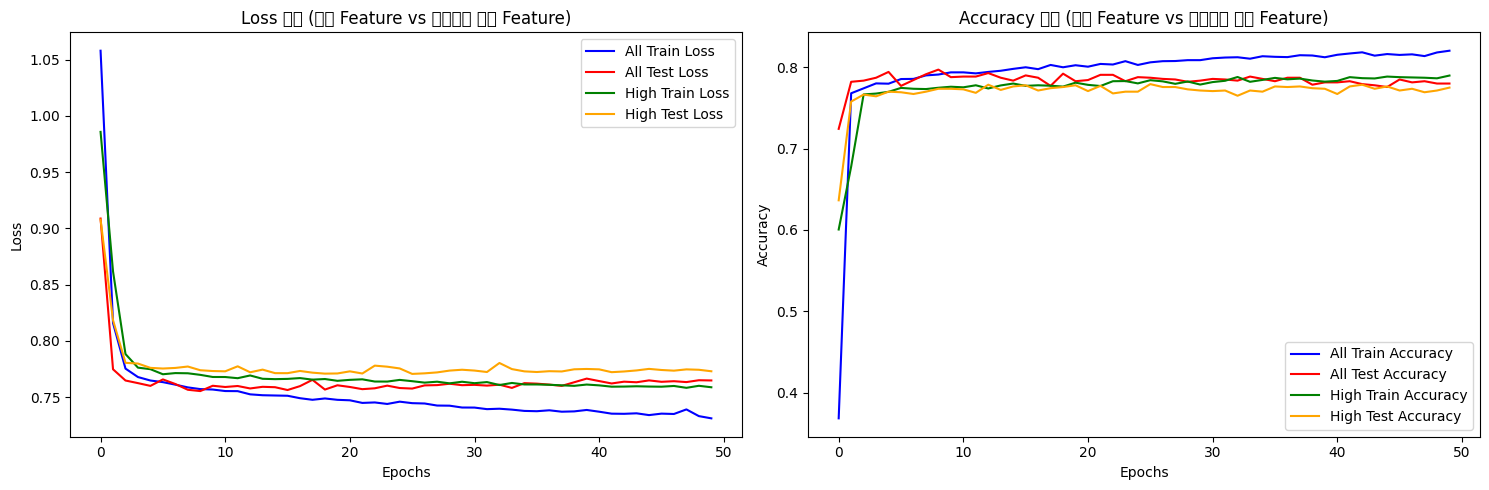

[전체 Feature]     Train Acc: 0.8204 | Test Acc: 0.7800
[높은 상관 Feature] Train Acc: 0.7898 | Test Acc: 0.7750


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_all['train_loss'],  label='All Train Loss',  color='blue')
axes[0].plot(history_all['test_loss'],   label='All Test Loss',   color='red')
axes[0].plot(history_high['train_loss'], label='High Train Loss', color='green')
axes[0].plot(history_high['test_loss'],  label='High Test Loss',  color='orange')
axes[0].set_title('Loss 비교 (전체 Feature vs 상관관계 높은 Feature)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_all['train_acc'],  label='All Train Accuracy',  color='blue')
axes[1].plot(history_all['test_acc'],   label='All Test Accuracy',   color='red')
axes[1].plot(history_high['train_acc'], label='High Train Accuracy', color='green')
axes[1].plot(history_high['test_acc'],  label='High Test Accuracy',  color='orange')
axes[1].set_title('Accuracy 비교 (전체 Feature vs 상관관계 높은 Feature)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"[전체 Feature]     Train Acc: {history_all['train_acc'][-1]:.4f} | Test Acc: {history_all['test_acc'][-1]:.4f}")
print(f"[높은 상관 Feature] Train Acc: {history_high['train_acc'][-1]:.4f} | Test Acc: {history_high['test_acc'][-1]:.4f}")

## 실험 결과

- Test Accuracy 기준: 전체 feature > 상관관계 높은 feature만 사용
- 결론: 상관계수가 낮은 feature라도 모델 학습에 미세한 패턴 기여 가능
- → 전체 feature(stress_level 제외)를 사용하는 것이 더 좋은 모델
- 다음 실험(experiment2)에서는 전체 feature 고정 후 정규화 방법 비교 예정